In [1]:
#importing necessary modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Setting the style of the plot and figure size
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

In [3]:
#Loading the dataset
df=pd.read_csv('store_orders.csv')
#Checking the first 5 rows of the dataset
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,04-01-2023,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,23-08-2024,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,27-02-2024,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,15-10-2023,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,08-05-2025,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
print('Shape of the dataset:', df.shape)
print("\nData types of the columns:\n", df.info())

Shape of the dataset: (1200, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    str    
 12  ReferralSource   1200 non-null   str    
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 131.4 KB

Data types of the columns:
 None


In [5]:
#Checking for missing values
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [6]:
#1. Convert Excel date format to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
# 2. Fill missing CouponCode
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

In [7]:
#3. Create useful columns for analysis
df['HasDiscount']=df['CouponCode']!='No Coupon'
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month
df['YearMonth']=df['Date'].dt.to_period('M')

In [8]:
# 4. Quick quality check
print(f'Missing Values \n{df.isnull().sum()}')
print(f'\nDuplicate OrderID {df.duplicated(subset=['OrderID'], keep='first').sum()}')

Missing Values 
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
HasDiscount        0
Year               0
Month              0
YearMonth          0
dtype: int64

Duplicate OrderID 0


In [9]:
# 5. Verify TotalPrice calculation (small floating-point differences are normal)
df['CalculatedTotal'] = df['Quantity'] * df['UnitPrice']
print("Max difference between TotalPrice and CalculatedTotal:", 
      (df['TotalPrice'] - df['CalculatedTotal']).abs().max())

Max difference between TotalPrice and CalculatedTotal: 4.547473508864641e-13


In [10]:
print("=== BASIC STORE SNAPSHOT ===")
print(f'Total Orders :{len(df)}')
print(f"Total Revenue :{df['TotalPrice'].sum()} Rs.")
print(f'Average order value (AOV) :{df['TotalPrice'].mean()}')
print("\nOrder Status breakdown:\n", df['OrderStatus'].value_counts(normalize=True)*100)
print(f'\nTop 5 products :{df['Product'].value_counts().head(5)}')

=== BASIC STORE SNAPSHOT ===
Total Orders :1200
Total Revenue :1264761.96 Rs.
Average order value (AOV) :1053.9683

Order Status breakdown:
 OrderStatus
Cancelled    20.833333
Returned     20.583333
Pending      19.750000
Shipped      19.583333
Delivered    19.250000
Name: proportion, dtype: float64

Top 5 products :Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Name: count, dtype: int64


In [11]:
# Question 1: Is sales improving?
# Monthly revenue trend
monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

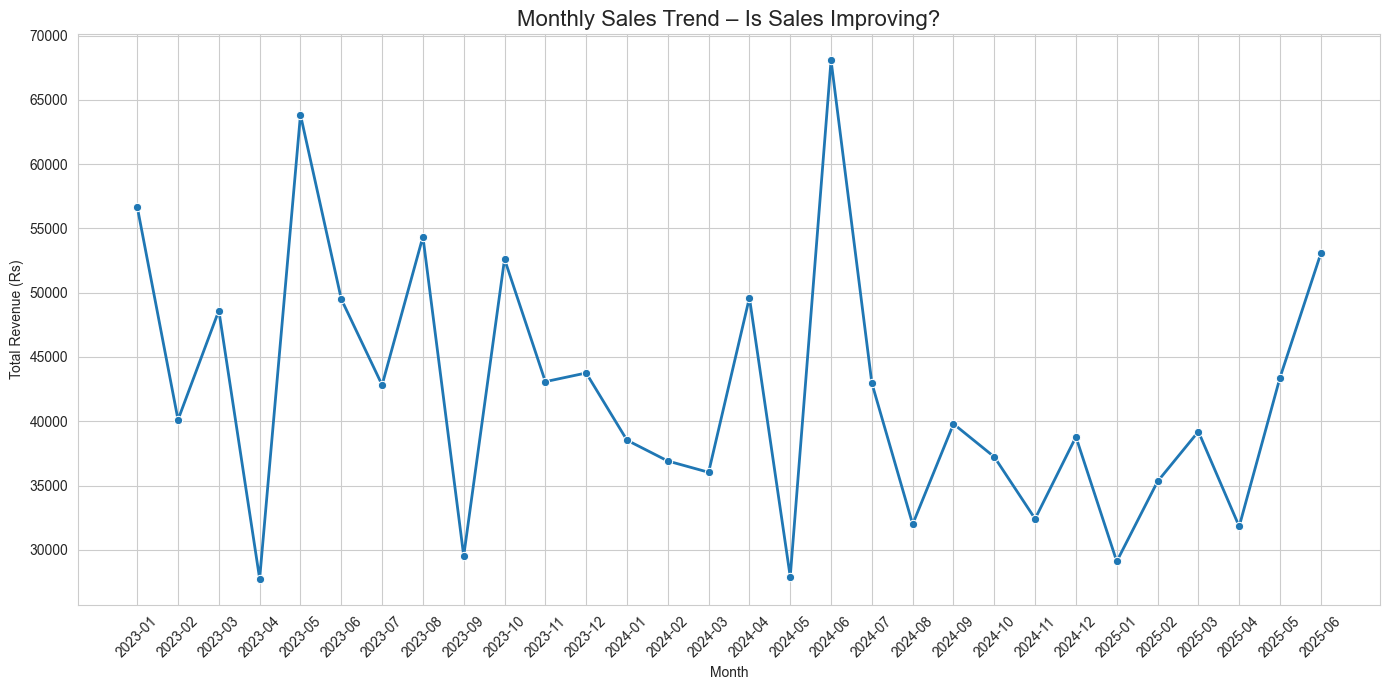

In [12]:
plt.figure(figsize=(14,7))
sns.lineplot(data=monthly_sales, x='YearMonth', y='TotalPrice', marker='o', linewidth=2)
plt.title('Monthly Sales Trend – Is Sales Improving?', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Revenue (Rs)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# Year-over-year comparison
yearly_sales = df.groupby('Year')['TotalPrice'].sum().reset_index()
print("Yearly Sales:\n", yearly_sales)

Yearly Sales:
    Year  TotalPrice
0  2023   552643.24
1  2024   480235.87
2  2025   231882.85


In [14]:
# Growth rate (last 3 months)
monthly_sales['Growth_%'] = monthly_sales['TotalPrice'].pct_change()*100
print("\nRecent Monthly Growth Rates (%):\n", monthly_sales.tail(6)[['YearMonth', 'Growth_%']])


Recent Monthly Growth Rates (%):
    YearMonth   Growth_%
24   2025-01 -24.974030
25   2025-02  21.368654
26   2025-03  10.994845
27   2025-04 -18.824836
28   2025-05  36.376504
29   2025-06  22.238496


In [15]:
# Question 2: Are we losing money by applying discounts?
# 1. Overall discount impact
discount_summary = df.groupby('HasDiscount').agg(
    Total_Revenue=('TotalPrice', 'sum'),
    Num_Orders=('OrderID', 'count'),
    Avg_Order_Value=('TotalPrice', 'mean'),
    Avg_Quantity=('Quantity', 'mean')
).round(2)

print("Discount vs No-Discount Performance:\n", discount_summary)

Discount vs No-Discount Performance:
              Total_Revenue  Num_Orders  Avg_Order_Value  Avg_Quantity
HasDiscount                                                          
False            322401.41         309          1043.37          3.05
True             942360.55         891          1057.64          2.91


In [16]:
# 2. Success rate (Shipped + Delivered)
def success_rate(x):
    successful = x.isin(['Shipped', 'Delivered']).sum()
    return round(successful / len(x) * 100, 2)

success_by_discount = df.groupby('HasDiscount')['OrderStatus'].apply(success_rate)
print("\nSuccess Rate (%):\n", success_by_discount)


Success Rate (%):
 HasDiscount
False    37.54
True     39.28
Name: OrderStatus, dtype: float64


In [17]:
# 3. Return rate (important for "losing money")
return_rate = df.groupby('HasDiscount')['OrderStatus'].apply(lambda x: round((x == 'Returned').mean() * 100, 2))
print("\nReturn Rate (%):\n", return_rate)


Return Rate (%):
 HasDiscount
False    24.60
True     19.19
Name: OrderStatus, dtype: float64


In [18]:
# 4. Detailed by coupon type
coupon_perf = df[df['HasDiscount']].groupby('CouponCode').agg(
    Total_Revenue=('TotalPrice', 'sum'),
    Num_Orders=('OrderID', 'count'),
    AOV=('TotalPrice', 'mean')
).round(2).sort_values('Total_Revenue', ascending=False)
print("\nPerformance by Coupon Type:\n", coupon_perf)


Performance by Coupon Type:
             Total_Revenue  Num_Orders      AOV
CouponCode                                    
FREESHIP        335036.99         313  1070.41
SAVE10          304840.02         286  1065.87
WINTER15        302483.54         292  1035.90


Platform Performance (sorted by revenue):
                 Total_Revenue  Num_Orders      AOV  Avg_ItemsInCart
ReferralSource                                                     
Instagram           275285.45         259  1062.88             5.50
Email               261808.55         250  1047.23             5.60
Google              250441.48         241  1039.18             5.57
Facebook            250410.90         228  1098.29             5.33
Referral            226815.58         222  1021.69             5.40


C:\Users\Administrator\AppData\Local\Temp\ipykernel_17880\2726587258.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=platform_perf.reset_index(), x='ReferralSource', y='Total_Revenue', palette='viridis')


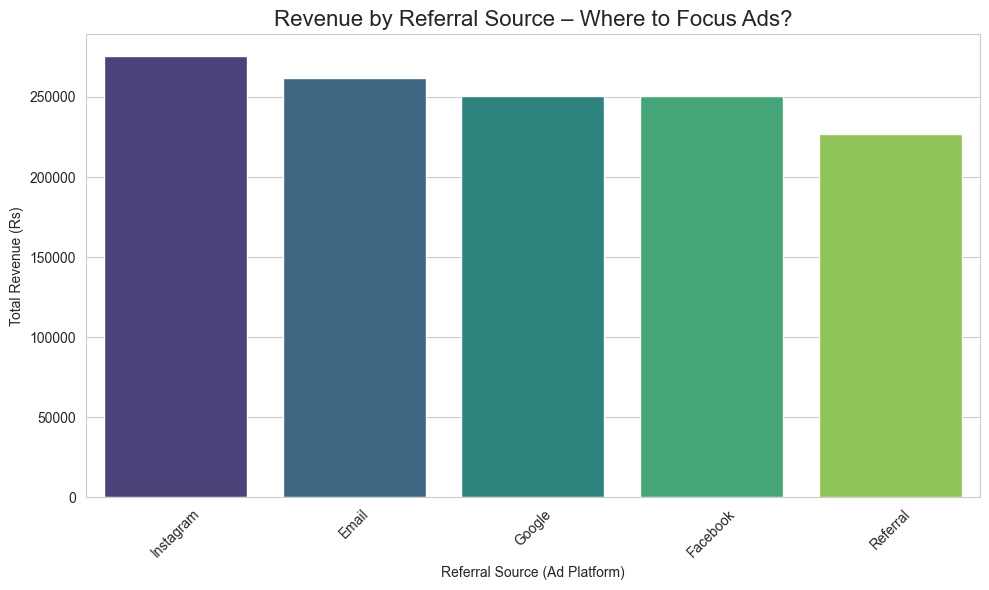


Revenue Share by Platform (%):
                 Total_Revenue  Revenue_%
ReferralSource                          
Instagram           275285.45       21.8
Email               261808.55       20.7
Google              250441.48       19.8
Facebook            250410.90       19.8
Referral            226815.58       17.9


In [19]:
# Question 3: On which platform should I improve my ads?
platform_perf = df.groupby('ReferralSource').agg(
    Total_Revenue=('TotalPrice', 'sum'),
    Num_Orders=('OrderID', 'count'),
    AOV=('TotalPrice', 'mean'),
    Avg_ItemsInCart=('ItemsInCart', 'mean')
).round(2).sort_values('Total_Revenue', ascending=False)

print("Platform Performance (sorted by revenue):\n", platform_perf)

# Visual
plt.figure(figsize=(10,6))
sns.barplot(data=platform_perf.reset_index(), x='ReferralSource', y='Total_Revenue', palette='viridis')
plt.title('Revenue by Referral Source – Where to Focus Ads?', fontsize=16)
plt.xlabel('Referral Source (Ad Platform)')
plt.ylabel('Total Revenue (Rs)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Percentage contribution
platform_perf['Revenue_%'] = (platform_perf['Total_Revenue'] / platform_perf['Total_Revenue'].sum() * 100).round(1)
print("\nRevenue Share by Platform (%):\n", platform_perf[['Total_Revenue', 'Revenue_%']])

In [20]:
# 1. Top products by revenue
product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(product_revenue)

# 2. Correlation: bigger cart → higher value?
print("\nCorrelation between ItemsInCart and TotalPrice:", df['ItemsInCart'].corr(df['TotalPrice']))

# 3. Cancellation/Return rate by platform
status_by_platform = df.groupby(['ReferralSource', 'OrderStatus']).size().unstack(fill_value=0)
print(status_by_platform)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

Correlation between ItemsInCart and TotalPrice: 0.3925402604068665
OrderStatus     Cancelled  Delivered  Pending  Returned  Shipped
ReferralSource                                                  
Email                  59         60       46        49       36
Facebook               42         42       39        56       49
Google                 58         44       47        43       49
Instagram              41         52       69        55       42
Referral               50         33       36        44       59
